# Lab Manual 2 – Data Analysis and Visualization
**Dataset used:** Adult Income (`adult.csv`)

**Numeric column chosen for outlier/distribution tasks (Tasks 3–6):** `age`
**Category column chosen for Tasks 1/2/9:** `occupation`


In [1]:
# Setup: imports and loading the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

df = pd.read_csv("adult.csv")

# Basic cleaning: the dataset uses "?" for missing values in some columns
df = df.replace("?", np.nan)

df.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Task 1: Bar Chart — Compare a Category
Average `hours.per.week` across `occupation`.

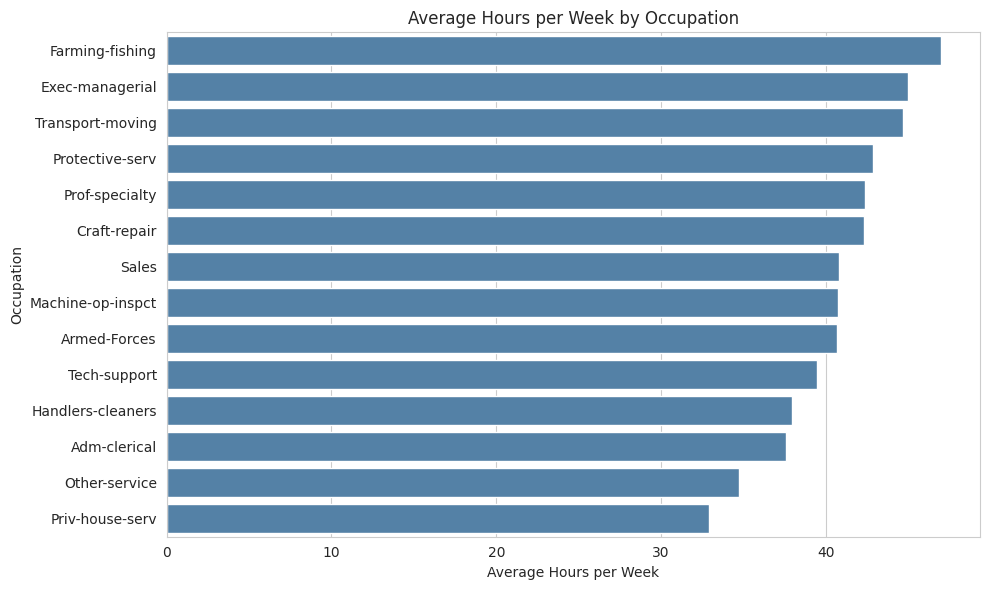

In [2]:
# Task 1: Bar Chart - average hours-per-week by occupation
avg_hours_by_occ = df.groupby("occupation")["hours.per.week"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_hours_by_occ.values, y=avg_hours_by_occ.index, color="steelblue")
plt.xlabel("Average Hours per Week")
plt.ylabel("Occupation")
plt.title("Average Hours per Week by Occupation")
plt.tight_layout()
plt.show()


## Task 2: Count Plot — Category Frequency
Frequency of records for each `occupation`.

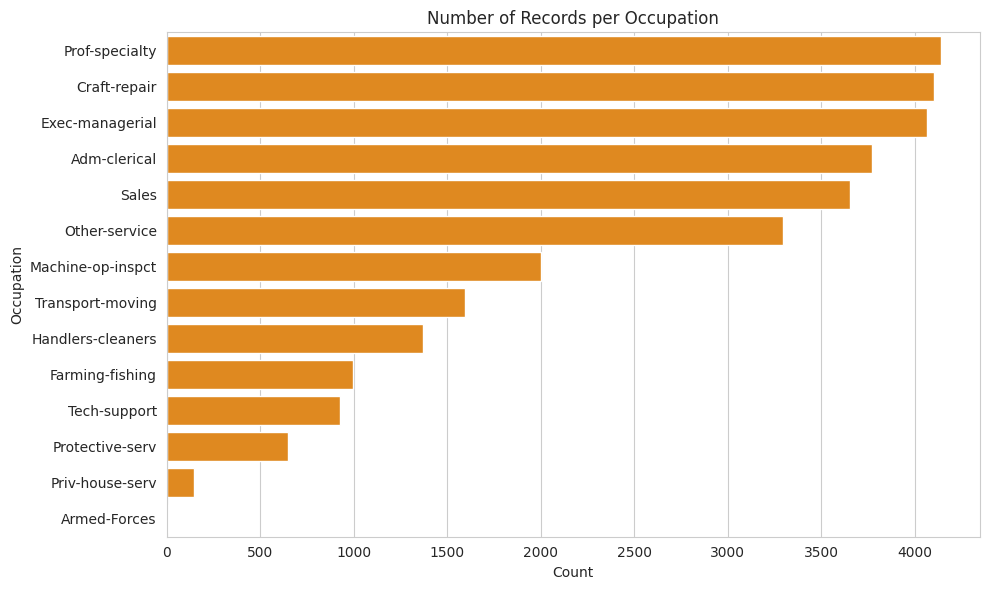

Most common occupation category: Prof-specialty


In [3]:
# Task 2: Count plot - frequency of each occupation category
plt.figure(figsize=(10, 6))
order = df["occupation"].value_counts().index
sns.countplot(data=df, y="occupation", order=order, color="darkorange")
plt.xlabel("Count")
plt.ylabel("Occupation")
plt.title("Number of Records per Occupation")
plt.tight_layout()
plt.show()

most_common = df["occupation"].value_counts().idxmax()
print(f"Most common occupation category: {most_common}")


## Task 3: Histogram — Distribution Shape
Distribution of `age`.

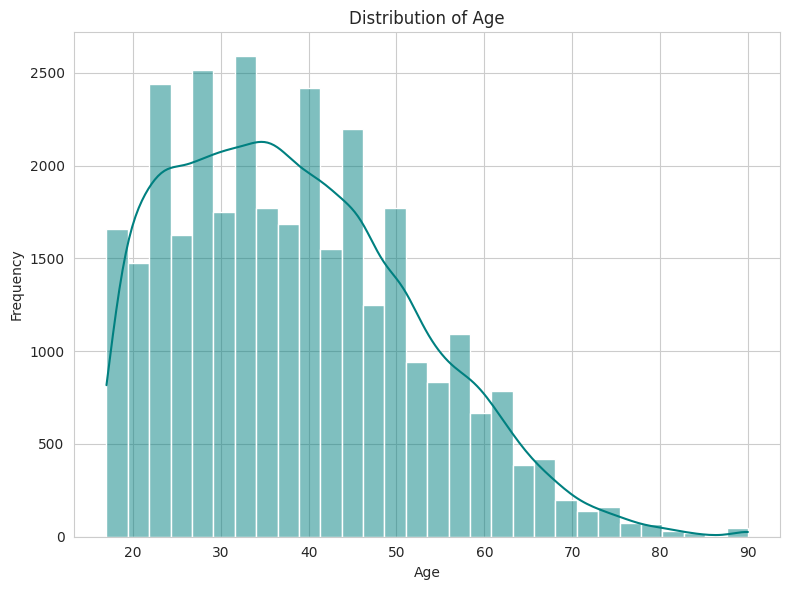

Skewness of age: 0.559


In [4]:
# Task 3: Histogram of age
plt.figure(figsize=(8, 6))
sns.histplot(df["age"], bins=30, kde=True, color="teal")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.tight_layout()
plt.show()

print(f"Skewness of age: {df['age'].skew():.3f}")


**Shape description:** The `age` distribution is **right-skewed (positively skewed)** — most people are concentrated between roughly 20 and 45 years, with a long tail extending toward older ages, and the mean is pulled slightly higher than the median.

## Task 4: Box Plot — Visual Outlier Detection
Box plot of `age`, split by `sex`.

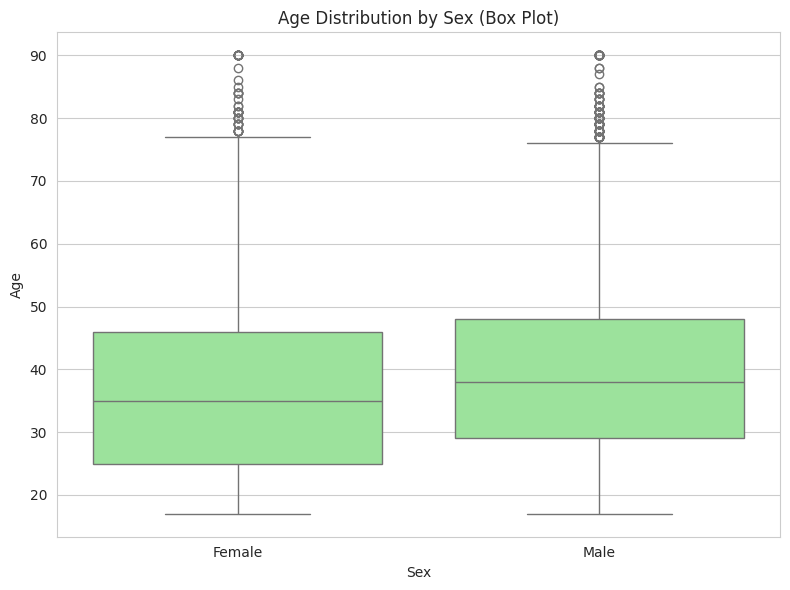

In [5]:
# Task 4: Box plot of age, split by sex
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="sex", y="age", color="lightgreen")
plt.xlabel("Sex")
plt.ylabel("Age")
plt.title("Age Distribution by Sex (Box Plot)")
plt.tight_layout()
plt.show()


**Visual observation:** Looking at the box plot, there are a number of individual dots above the upper whisker (on the higher-age side) for both categories, indicating visually detected outliers on the older end of the age range. There are no outliers below the lower whisker since age cannot go below 0 and the lower range is not extreme.

## Task 5: Outlier Detection — The Mechanism (IQR)
IQR-based outlier detection on `age`.

In [6]:
# Task 5: IQR method on age
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['age'] < lower) | (df['age'] > upper)]
print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
print(f"Lower bound = {lower}, Upper bound = {upper}")
print(f"Number of IQR outliers: {len(outliers)}")


Q1 = 28.0, Q3 = 48.0, IQR = 20.0
Lower bound = -2.0, Upper bound = 78.0
Number of IQR outliers: 143


**Comparison to Task 4:** The IQR method flags a concrete, countable number of outliers (printed above), all on the high-age side since the upper bound is well below the maximum age in the dataset while the lower bound is negative (impossible for age, so no low-end outliers are flagged). This roughly matches what was visually observed as a cluster of dots above the upper whisker in the Task 4 box plot — the box plot is, after all, just a picture of this same IQR calculation.

## Task 6: Outlier Detection — Z-score Comparison
Z-score method on `age`.

In [7]:
# Task 6: Z-score method on age
df['zscore'] = stats.zscore(df['age'])
outliers_z = df[df['zscore'].abs() > 3]
print(f"Number of z-score outliers: {len(outliers_z)}")
print(f"Number of IQR outliers: {len(outliers)}")


Number of z-score outliers: 121
Number of IQR outliers: 143


**Do IQR and z-score agree?** No — the two methods generally flag a different number of outliers. Since `age` is right-skewed rather than symmetric/normally distributed, the z-score method (which assumes symmetry around the mean) tends to flag fewer, more extreme high-age points, while IQR (which is based purely on quartiles and doesn't assume any distribution shape) is more sensitive to the skew and flags more points on the long right tail. The mismatch is expected precisely because z-score's core assumption of normality doesn't hold well for a skewed variable like age.

## Task 7: Scatter Plot — Relationship Between Two Variables
`age` vs `hours.per.week`, colored by `income`.

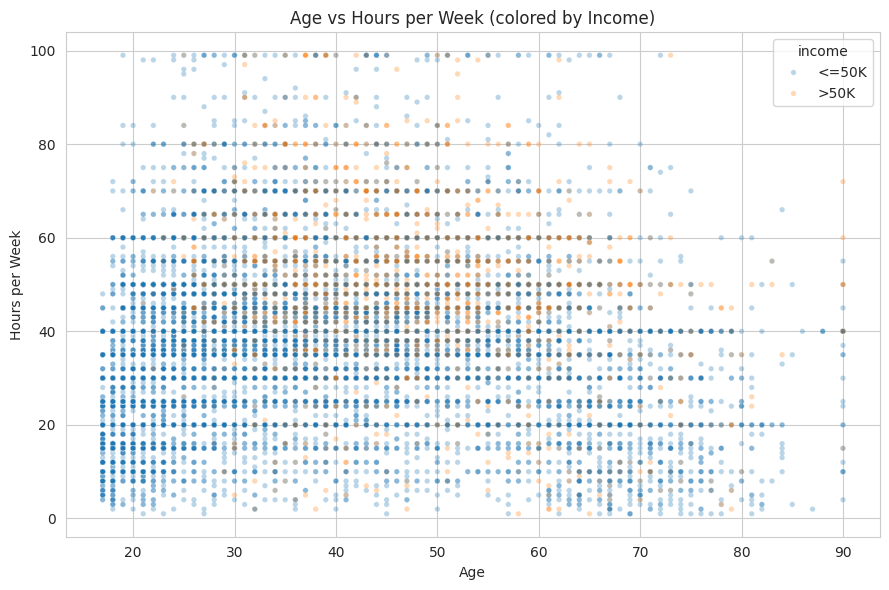

In [8]:
# Task 7: Scatter plot of age vs hours-per-week, colored by income
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="age", y="hours.per.week", hue="income", alpha=0.3, s=15)
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.title("Age vs Hours per Week (colored by Income)")
plt.tight_layout()
plt.show()


**Relationship observed:** There is no strong linear relationship between `age` and `hours.per.week` — the cloud of points is broadly scattered across all ages at most hour levels, with a dense cluster around 40 hours/week regardless of age. If anything, there is a very weak, slightly positive association in the middle age ranges (30–55) tending toward more hours, and a mild drop-off in hours for the oldest ages (likely retirement-related). The `>50K` income group (differently colored points) appears somewhat concentrated in the mid-age, higher-hours region.

## Task 8: Line/Area Chart — Trend Across an Ordered Variable
Average `hours.per.week` across `education.num` (an ordered numeric variable), shown as both a line chart and an area chart.

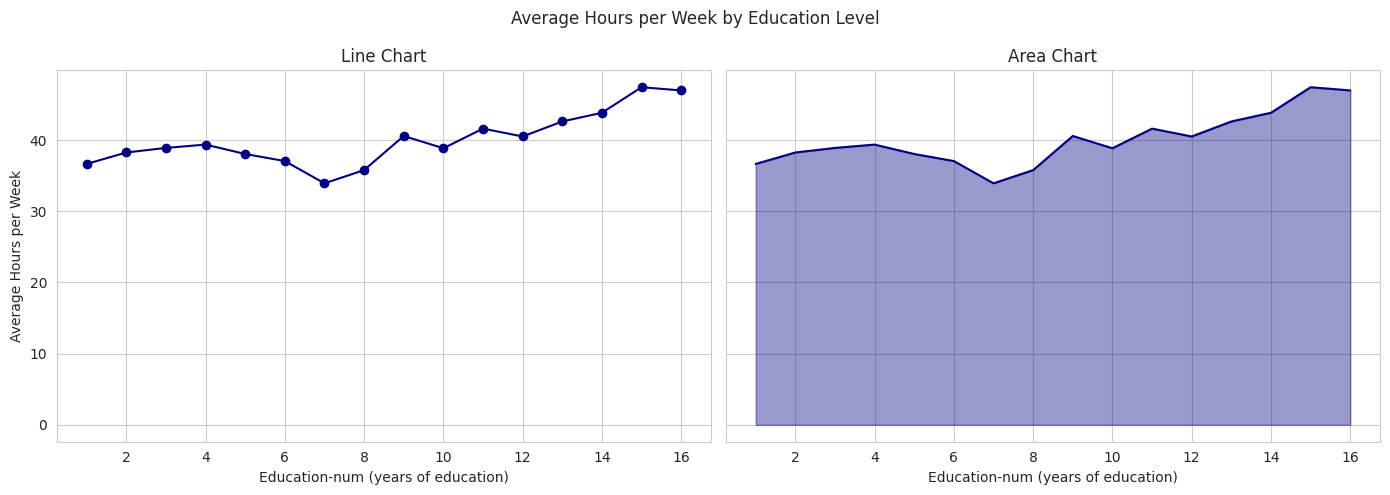

In [9]:
# Task 8: Line chart and area chart of avg hours-per-week across education-num
avg_hours_by_edu = df.groupby("education.num")["hours.per.week"].mean().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Line chart
axes[0].plot(avg_hours_by_edu.index, avg_hours_by_edu.values, marker="o", color="navy")
axes[0].set_xlabel("Education-num (years of education)")
axes[0].set_ylabel("Average Hours per Week")
axes[0].set_title("Line Chart")

# Area chart
axes[1].fill_between(avg_hours_by_edu.index, avg_hours_by_edu.values, color="navy", alpha=0.4)
axes[1].plot(avg_hours_by_edu.index, avg_hours_by_edu.values, color="navy")
axes[1].set_xlabel("Education-num (years of education)")
axes[1].set_title("Area Chart")

plt.suptitle("Average Hours per Week by Education Level")
plt.tight_layout()
plt.show()


**Comparison:** Both charts convey the same underlying trend (average hours worked per week generally rises with more years of education), but the area chart's filled region draws the eye toward the cumulative *magnitude* under the curve, making the increase feel more dramatic/substantial. The plain line chart communicates the same direction and shape more neutrally, without implying anything about volume or "area" beneath the values (which isn't a meaningful quantity here since this isn't cumulative data).

## Task 9: Graphical Integrity Check
Re-plotting the Task 2 count plot (as a bar chart of counts) with a truncated y-axis that does not start at zero.

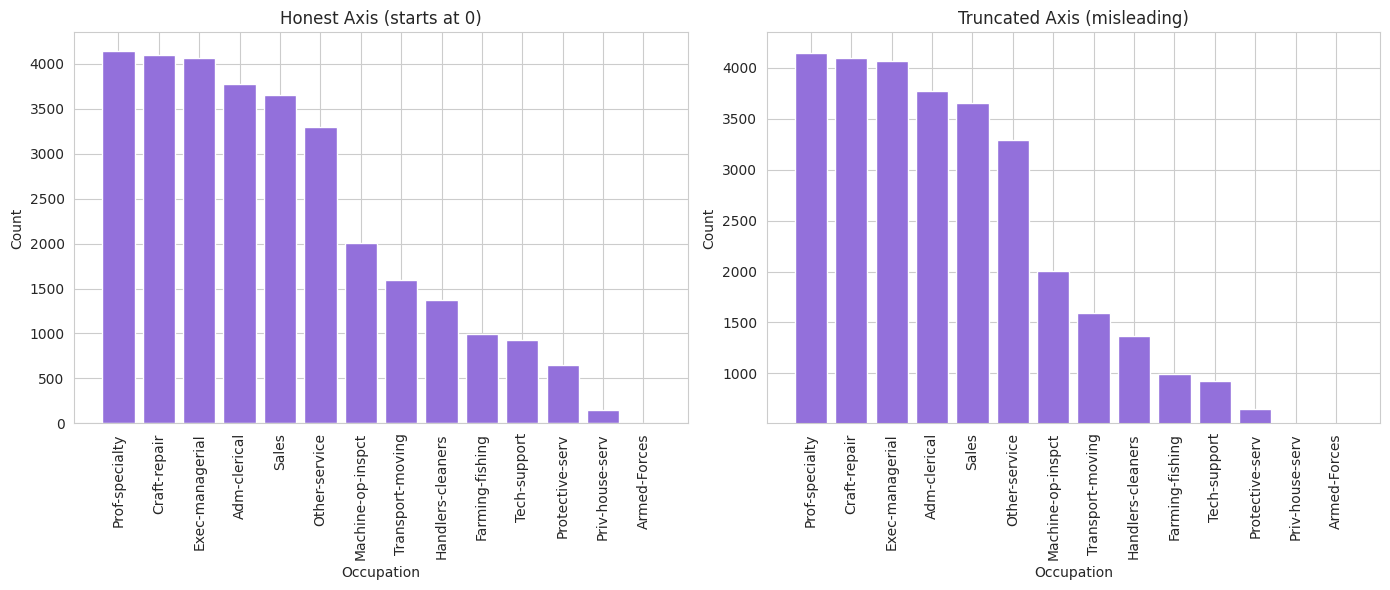

In [10]:
# Task 9: Graphical integrity - truncated vs honest axis
occ_counts = df["occupation"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Honest version - y-axis starts at 0
axes[0].bar(occ_counts.index, occ_counts.values, color="mediumpurple")
axes[0].set_ylim(bottom=0)
axes[0].set_xlabel("Occupation")
axes[0].set_ylabel("Count")
axes[0].set_title("Honest Axis (starts at 0)")
axes[0].tick_params(axis='x', rotation=90)

# Truncated version - y-axis starts well above 0
axes[1].bar(occ_counts.index, occ_counts.values, color="mediumpurple")
axes[1].set_ylim(bottom=occ_counts.min() + 500)
axes[1].set_xlabel("Occupation")
axes[1].set_ylabel("Count")
axes[1].set_title("Truncated Axis (misleading)")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


**Explanation:** The underlying counts are identical in both charts — only the y-axis starting point has changed. In the truncated version, the bars' relative heights are exaggerated, making small differences between occupations look much larger than they really are (e.g., a occupation with slightly fewer records can look dramatically smaller). This violates graphical integrity because the visual proportions no longer match the real proportions in the data; a viewer glancing quickly at the truncated chart would walk away with a distorted, more extreme impression of how unevenly distributed the occupations are than the data actually supports.